In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('loan_data.csv')

# Summary Statics
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        949 non-null    float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None


### Handling Missing Values 

In [2]:
df['income'] = df['income'].fillna(df['income'].median())

# Summary statics 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        1000 non-null   float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None


### Step 2: Visualizing  Correlation
understanding how variables interact is key to risk assesment

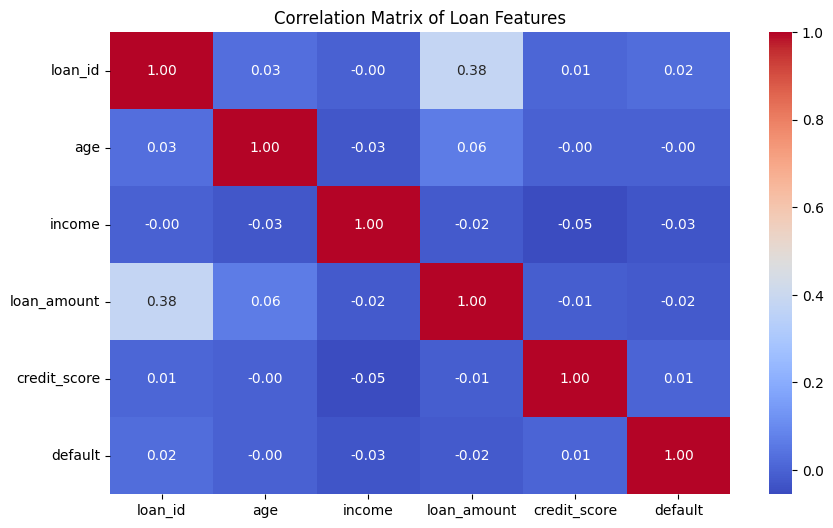

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix of Loan Features")
plt.show()

### Step 3: Outlier Detection

We use a boxplot to see if certain loan amounts are unrealistic compared to the rest of the data.

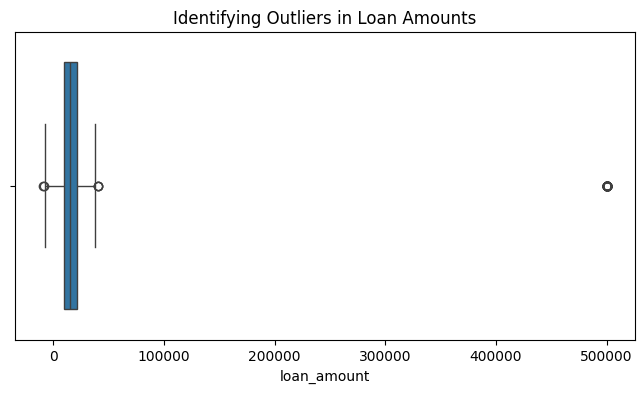

In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['loan_amount'])
plt.title("Identifying Outliers in Loan Amounts")
plt.show()

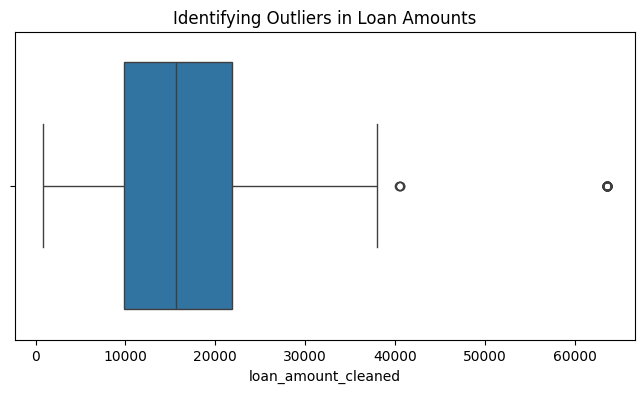

In [6]:
# Clipping outliers to the 90th percentile
qu_limit = df['loan_amount'].quantile(0.95)
ql_limit = df['loan_amount'].quantile(0.05)
df['loan_amount_cleaned'] = df['loan_amount'].clip(upper=qu_limit, lower=ql_limit)

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['loan_amount_cleaned'])
plt.title("Identifying Outliers in Loan Amounts")
plt.show()

### Step 4: Feature Engineering

We create a Debt-to-Income (DTI) Ratio and a Risk Score to provide more signal for an AI model.

In [7]:
# Create new features
df['dti_ratio'] = df['loan_amount_cleaned'] / df['income']

# Categorize credit scores into 'Risk Levels'
bins = [300, 580, 670, 740, 850]
labels = ['High Risk', 'Fair', 'Good', 'Excellent']
df['risk_category'] = pd.cut(df['credit_score'], bins=bins, labels=labels)

print(df[['income', 'dti_ratio', 'risk_category']].head())

    income  dti_ratio risk_category
0  49712.0   0.231634     High Risk
1  49712.0   0.536551          Good
2  49712.0   0.226645     High Risk
3  49712.0   0.232560     High Risk
4  49712.0   0.388558     High Risk


### Step 5: Findings Summary

In [8]:
# Quick analysis of default rates by risk category
summary = df.groupby('risk_category', observed=False)['default'].mean() * 100
print(f"Default Percentage by Category:\n{summary}")

Default Percentage by Category:
risk_category
High Risk    19.311663
Fair         20.779221
Good         19.259259
Excellent    22.994652
Name: default, dtype: float64


# Project Summary

Missing Values: Handled using median imputation to maintain data distribution.

Outliers: Identified extreme loan_amount values that could skew model training.

Features: Engineered dti_ratio, which is often more predictive than income alone.

Insight: Higher risk categories show a clear correlation with actual defaults.